## EnTex Spliser Analysis
The primary goal is to identify splicing sites with largest tissue specificity

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

import omics_utils
import importlib
importlib.reload(omics_utils)

tissue_records = omics_utils.spliser_get_tissue_records(dataset_dir="data/entex/RNA-seq_dataset/", tsv_pattern="*.SpliSER.tsv")

print(f"Processing {len(tissue_records)} tissues for DESeq2 wide-format dataframes...\n")

for i, tissue_record in enumerate(tissue_records[:3]):
    tissue_name = tissue_record['name']
    combined_tsv_file = tissue_record['combined_tsv_file']

    print(f"Tissue {i+1}/{len(tissue_records)}: {tissue_name}", end=" ... ")

    try:
        # Check if file exists
        if not os.path.exists(combined_tsv_file):
            print(f"⚠ SKIP: combined_tsv_file not found at {combined_tsv_file}")
            continue

        # Read combined TSV
        combined_df = pd.read_csv(combined_tsv_file, sep='\t', comment='#')
        print(f"(loaded {len(combined_df)} rows)", end=" ... ")

        # Build DESeq2-ready wide-format dataframe
        wide_df = omics_utils.spliser_combined_to_deseq2_df(combined_df, group_prefix=f"{tissue_name}_")

        # Store in tissue_record
        tissue_record['deseq2_wide_df'] = wide_df

        # Validation checks
        num_samples = len(combined_df['Sample'].unique())
        num_sites = len(wide_df)
        num_cols = len(wide_df.columns)

        # Check for NaN
        has_nan = wide_df.isnull().sum().sum()

        # Print summary
        print(f"✓ Done: {num_sites} sites, {num_samples} samples, {num_cols} columns", end="")
        if has_nan > 0:
            print(f" [WARNING: {has_nan} NaN values found]")
        else:
            print()

    except Exception as e:
        print(f"✗ ERROR: {str(e)}")
        continue

tissue_records[0]['deseq2_wide_df'].head()

ModuleNotFoundError: No module named 'pyfaidx'

In [ ]:
# Combine all deseq2_wide_df tables across tissues using outer join on the shared multi-index
wide_dfs = [
    tr["deseq2_wide_df"]
    for tr in tissue_records
    if "deseq2_wide_df" in tr and tr["deseq2_wide_df"] is not None
    and not tr["deseq2_wide_df"].empty
]

if not wide_dfs:
    raise ValueError("No non-empty 'deseq2_wide_df' dataframes found in tissue_records.")

print(f"Combining {len(wide_dfs)} wide-format dataframes with outer join...")
combined_deseq2_wide_df = pd.concat(wide_dfs, axis=1, join="outer").fillna(0)

sse_cols = [c for c in combined_deseq2_wide_df.columns if str(c).endswith("_SSE")]
if not sse_cols:
    raise ValueError("No columns ending with _SSE found for average-based filtering.")

# Filter out rows where mean is < 0.05 or > 0.95
row_avg_sse = combined_deseq2_wide_df[sse_cols].mean(axis=1)
filtered_deseq2_wide_df = combined_deseq2_wide_df[(row_avg_sse >= 0.05) & (row_avg_sse <= 0.95)].copy()

# Filter out rows where all SSE values differ by less than 0.05
sse_max = filtered_deseq2_wide_df[sse_cols].max(axis=1)
sse_min = filtered_deseq2_wide_df[sse_cols].min(axis=1)
filtered_deseq2_wide_df = filtered_deseq2_wide_df[(sse_max - sse_min) >= 0.05]

print(f"Combined shape: {combined_deseq2_wide_df.shape}")
print(f"Filtered shape: {filtered_deseq2_wide_df.shape}")
print(f"Rows removed: {len(combined_deseq2_wide_df) - len(filtered_deseq2_wide_df)}")
print(f"SSE columns used for averaging: {len(sse_cols)}")
filtered_deseq2_wide_df.head()

# save to CSV for downstream use
filtered_deseq2_wide_df.to_csv("entex_combined_deseq2_wide_df_filtered.csv", index=True)
print(f"\nFiltered combined dataframe saved to 'entex_combined_deseq2_wide_df_filtered.csv'.")

Combining 3 wide-format dataframes with outer join...
Combined shape: (1493907, 27)
Filtered shape: (424736, 27)
Rows removed: 1069171
SSE columns used for averaging: 9


In [ ]:
import sys
import subprocess
import importlib
import matplotlib.pyplot as plt

# Ensure compatible versions for PyDESeq2 in this kernel
def ensure_pydeseq2_runtime():
    try:
        import numpy as _np
        import anndata as _ad
        import pydeseq2 as _pd2
        _ = (_np.__version__, _ad.__version__, _pd2.__version__)
        return
    except Exception:
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install',
            'numpy<2',
            'anndata<0.11',
            'pydeseq2'
        ])
        importlib.invalidate_caches()

ensure_pydeseq2_runtime()

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

pd.options.display.float_format = '{:.6f}'.format

if 'filtered_deseq2_wide_df' not in globals():
    raise ValueError("filtered_deseq2_wide_df is missing. Run the combine/filter cells first.")

# Parse tissue/sample/data_type from columns formatted as: {tissue}_{sample}_{data_type}
all_cols = filtered_deseq2_wide_df.columns.astype(str).tolist()
count_cols = [c for c in all_cols if c.endswith('_alpha') or c.endswith('_beta')]
sse_cols = [c for c in all_cols if c.endswith('_SSE')]

if len(count_cols) == 0:
    raise ValueError("No alpha/beta count columns found in filtered_deseq2_wide_df.")

tissue_names = sorted(
    [tr['name'] for tr in tissue_records if 'deseq2_wide_df' in tr],
    key=len,
    reverse=True
)

def parse_col_name(col_name):
    data_type = col_name.rsplit('_', 1)[-1]
    base = col_name[:-(len(data_type) + 1)]
    for tissue in tissue_names:
        prefix = f"{tissue}_"
        if base.startswith(prefix):
            sample_id = base[len(prefix):]
            return tissue, sample_id, data_type
    print(f"Column name '{col_name}' does not match expected format, defaulting to split.")
    left, right = base.split('_', 1) if '_' in base else (base, '')
    return left, right, data_type

meta_rows = []
for c in count_cols:
    tissue, sample_id, eff = parse_col_name(c)
    meta_rows.append({
        'count_col': c,
        'tissue': tissue,
        'sample_id': sample_id,
        'Eff': eff,
        'Combo': f"{eff}.{tissue}"
    })

metadata = pd.DataFrame(meta_rows).set_index('count_col')

# Use existing feature index; if MultiIndex is present, collapse it to pipe-delimited IDs.
if isinstance(filtered_deseq2_wide_df.index, pd.MultiIndex):
    site_feature_ids = filtered_deseq2_wide_df.index.to_frame(index=False).astype(str).agg('|'.join, axis=1)
else:
    site_feature_ids = filtered_deseq2_wide_df.index.astype(str)

site_annotation = pd.DataFrame({'feature_id': site_feature_ids.values}).set_index('feature_id')

# Recover Region/Site/Strand/Gene when feature IDs are pipe-delimited.
parts = site_annotation.index.to_series().str.split('|', n=3, expand=True)
if parts.shape[1] == 4:
    parts.columns = ['Region', 'Site', 'Strand', 'Gene']
    site_annotation = parts.set_index(site_annotation.index)

feature_df = filtered_deseq2_wide_df[count_cols].copy()
feature_df.index = site_feature_ids.values

# Counts matrix for PyDESeq2: rows=samples(alpha/beta pseudo-samples), cols=sites
counts = feature_df.T
counts = counts.fillna(0).astype(float)

# Enforce non-negative integer counts for DESeq2 compatibility
n_neg_before = int((counts < 0).sum().sum())
if n_neg_before > 0:
    print(f"Found {n_neg_before} negative entries in count matrix; clipping to 0.")
counts = counts.clip(lower=0).round().astype('int64')

# Drop sites with very low information across all pseudo-samples
min_total_count = 10
site_total = counts.sum(axis=0)
keep_sites = site_total >= min_total_count
counts = counts.loc[:, keep_sites]
site_annotation = site_annotation.loc[counts.columns]

print(f"Input count columns (alpha+beta): {len(count_cols)}")
print(f"SSE/SEE columns available for interpretation: {len(sse_cols)}")
print(f"Counts matrix shape (pseudo-samples x sites): {counts.shape}")
print(f"Unique tissues: {metadata['tissue'].nunique()}")
print(metadata.groupby(['tissue', 'Eff']).size().unstack(fill_value=0).head())

Found 8 negative entries in count matrix; clipping to 0.
Input count columns (alpha+beta): 18
SSE/SEE columns available for interpretation: 9
Counts matrix shape (pseudo-samples x sites): (18, 349684)
Unique tissues: 3
Eff              alpha  beta
tissue                      
Peyer-s-patch        4     4
adrenal-gland        4     4
ascending-aorta      1     1


Eff,alpha,beta
tissue,,
Peyer-s-patch,4,4
adrenal-gland,4,4
ascending-aorta,1,1


Top 10 pseudo-sample library sizes:


Peyer-s-patch_ENCBS168WDM_beta     62791378
adrenal-gland_ENCBS724UYV_beta     60395763
Peyer-s-patch_ENCBS231DCI_beta     52364370
Peyer-s-patch_ENCBS943XLR_beta     46864765
adrenal-gland_ENCBS006KAW_beta     44855386
adrenal-gland_ENCBS724UYV_alpha    42121949
adrenal-gland_ENCBS227VDO_beta     36769882
adrenal-gland_ENCBS423TBO_beta     36360202
adrenal-gland_ENCBS006KAW_alpha    35007675
adrenal-gland_ENCBS227VDO_alpha    28907787
dtype: int64

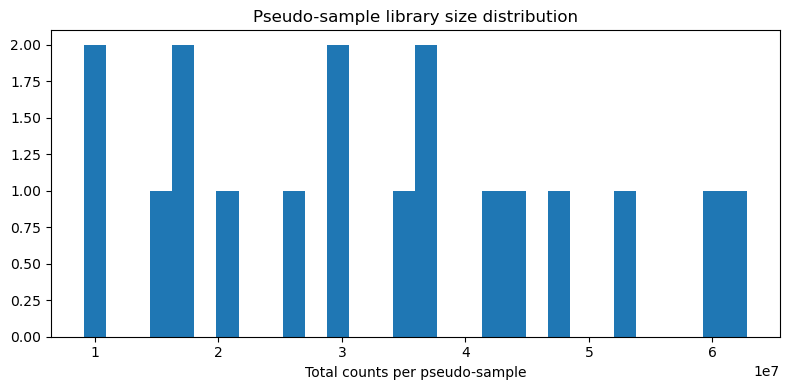

Metadata aligned to counts: (18, 4)


In [40]:
# Basic QC on tissue balance and library sizes
balance_tbl = metadata.groupby(['tissue', 'Eff']).size().unstack(fill_value=0).sort_index()
display(balance_tbl)

lib_sizes = counts.sum(axis=1).sort_values(ascending=False)
print("Top 10 pseudo-sample library sizes:")
display(lib_sizes.head(10))

plt.figure(figsize=(8, 4))
plt.hist(lib_sizes, bins=30)
plt.title('Pseudo-sample library size distribution')
plt.xlabel('Total counts per pseudo-sample')
plt.tight_layout()
plt.show()

# Check for duplicated metadata index
if metadata.index.duplicated().any():
    dup_n = metadata.index.duplicated().sum()
    raise ValueError(f"Found {dup_n} duplicated count column labels in metadata index.")

# Ensure metadata rows align exactly to count matrix rows
metadata = metadata.loc[counts.index]
print(f"Metadata aligned to counts: {metadata.shape}")

In [41]:
# Build PyDESeq2 dataset using tissue-specific alpha/beta combinations
dds = DeseqDataSet(
    counts=counts,
    metadata=metadata,
    design_factors='Combo',
    refit_cooks=True
)

print("DeseqDataSet initialized")
print(f"n pseudo-samples: {dds.n_obs}")
print(f"n splice sites: {dds.n_vars}")

DeseqDataSet initialized
n pseudo-samples: 18
n splice sites: 349684


/tmp/ipykernel_2840635/155874911.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


In [ ]:
# Fit DESeq2 model once, then reuse
if 'LFC' not in dds.varm:
    dds.deseq2()

print("DESeq2 fitting complete")
disp_preview = dds.varm['dispersions'][:5] if 'dispersions' in dds.varm else 'dispersion values unavailable'
print("First 5 dispersions:")
print(disp_preview)

DESeq2 fitting complete
First 5 dispersions:
[ 9.38385342 16.87748048 13.16043091  9.78907819 11.12621467]


In [ ]:
# Tissue-vs-reference contrasts on alpha/beta interaction-style effect
tissues = sorted(metadata['tissue'].unique())
if len(tissues) < 2:
    raise ValueError("Need at least two tissues for cross-tissue differential analysis.")

reference_tissue = tissues[0]
print(f"Reference tissue: {reference_tissue}")

tissue_sse_means = {}
for tissue in tissues:
    tissue_cols = [
        c for c in sse_cols
        if c.startswith(f"{tissue}_")
    ]
    if len(tissue_cols) > 0:
        tissue_sse_means[tissue] = filtered_deseq2_wide_df[tissue_cols].mean(axis=1)
        tissue_sse_means[tissue].index = filtered_deseq2_wide_df.index.astype(str)

contrast_results = []
for tissue in tissues:
    if tissue == reference_tissue:
        continue

    contrast = [
        'Combo',
        f'alpha.{tissue}',
        f'beta.{tissue}',
        f'alpha.{reference_tissue}',
        f'beta.{reference_tissue}'
    ]

    print(f"Running contrast: {tissue} vs {reference_tissue}")
    stat_res = DeseqStats(dds, contrast=contrast)
    stat_res.summary()

    res = stat_res.results_df.copy()
    res['tissue_test'] = tissue
    res['tissue_ref'] = reference_tissue
    res = res.join(site_annotation, how='left')

    if tissue in tissue_sse_means and reference_tissue in tissue_sse_means:
        res[f'delta_sse_{tissue}_vs_{reference_tissue}'] = (
            tissue_sse_means[tissue] - tissue_sse_means[reference_tissue]
        ).reindex(res.index)

    contrast_results.append(res)

if len(contrast_results) == 0:
    raise ValueError("No tissue contrasts were generated.")

all_results = pd.concat(contrast_results, axis=0)
print(f"Total result rows across contrasts: {len(all_results)}")
display(all_results.head())

Reference tissue: Peyer-s-patch


Running contrast: adrenal-gland vs Peyer-s-patch


Running Wald tests...
... done in 31.58 seconds.



Log2 fold change & Wald test p-value: Combo alpha.adrenal-gland vs beta.adrenal-gland
                                      baseMean  log2FoldChange    lfcSE  \
GL000008.2|84014|+|ENSG00000296732.1  0.953404       -3.991099 3.235270   
GL000008.2|84145|+|ENSG00000296732.1  0.549871       -1.607747 4.302115   
GL000008.2|85456|+|ENSG00000296732.1  0.948899       -2.397898 3.806092   
GL000008.2|85477|+|ENSG00000296732.1  1.078330       -1.991658 3.301178   
GL000008.2|85566|+|ENSG00000296732.1  0.765984        0.005039 3.586463   
...                                        ...             ...      ...   
chrX|150368612|+|ENSG00000013619.16   1.546590       -3.032174 4.951947   
chrY|11299237|-|-1                    0.861399       -3.032174 4.951947   
chrY|11300955|-|-1                    3.166556       -3.032174 4.951947   
chrY|11643363|+|-1                    1.504217       -3.032174 4.951947   
chrY|11721936|+|-1                    2.839980       -3.032174 4.951947   

             

Running Wald tests...
... done in 29.90 seconds.



Log2 fold change & Wald test p-value: Combo alpha.ascending-aorta vs beta.ascending-aorta
                                      baseMean  log2FoldChange    lfcSE  \
GL000008.2|84014|+|ENSG00000296732.1  0.953404       -2.518938 7.854387   
GL000008.2|84145|+|ENSG00000296732.1  0.549871       -2.518919 9.637599   
GL000008.2|85456|+|ENSG00000296732.1  0.948899       -2.518928 8.798380   
GL000008.2|85477|+|ENSG00000296732.1  1.078330       -2.518936 7.961036   
GL000008.2|85566|+|ENSG00000296732.1  0.765984       -2.518933 8.303235   
...                                        ...             ...      ...   
chrX|150368612|+|ENSG00000013619.16   1.546590        6.113445 9.288155   
chrY|11299237|-|-1                    0.861399       -1.255908 8.690012   
chrY|11300955|-|-1                    3.166556        3.589496 8.716785   
chrY|11643363|+|-1                    1.504217        6.073369 9.288198   
chrY|11721936|+|-1                    2.839980        0.171347 8.668628   

         

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tissue_test,tissue_ref,Region,Site,Strand,Gene,delta_sse_adrenal-gland_vs_Peyer-s-patch,delta_sse_ascending-aorta_vs_Peyer-s-patch
GL000008.2|84014|+|ENSG00000296732.1,0.953404,-3.991099,3.235270,-1.233622,0.217344,NaN,adrenal-gland,Peyer-s-patch,GL000008.2,84014,+,ENSG00000296732.1,-0.125000,NaN
GL000008.2|84145|+|ENSG00000296732.1,0.549871,-1.607747,4.302115,-0.373711,0.708619,NaN,adrenal-gland,Peyer-s-patch,GL000008.2,84145,+,ENSG00000296732.1,0.400000,NaN
GL000008.2|85456|+|ENSG00000296732.1,0.948899,-2.397898,3.806092,-0.630016,0.528684,NaN,adrenal-gland,Peyer-s-patch,GL000008.2,85456,+,ENSG00000296732.1,0.150000,NaN
GL000008.2|85477|+|ENSG00000296732.1,1.078330,-1.991658,3.301178,-0.603317,0.546298,NaN,adrenal-gland,Peyer-s-patch,GL000008.2,85477,+,ENSG00000296732.1,0.000000,NaN
GL000008.2|85566|+|ENSG00000296732.1,0.765984,0.005039,3.586463,0.001405,0.998879,NaN,adrenal-gland,Peyer-s-patch,GL000008.2,85566,+,ENSG00000296732.1,0.151750,NaN


In [45]:
# Significant hits and effect-size filter
hits = all_results[all_results['padj'] < 0.05].copy()

delta_cols = [c for c in hits.columns if c.startswith('delta_sse_')]
if len(delta_cols) > 0:
    max_abs_delta = hits[delta_cols].abs().max(axis=1)
    hits_sse_filtered = hits[max_abs_delta >= 0.10].copy()
else:
    hits_sse_filtered = hits.copy()

print(f"Significant hits (padj < 0.05): {len(hits)}")
print(f"After |delta_SSE| >= 0.10 filter: {len(hits_sse_filtered)}")
display(hits_sse_filtered.head())

Significant hits (padj < 0.05): 115878
After |delta_SSE| >= 0.10 filter: 75430


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tissue_test,tissue_ref,Region,Site,Strand,Gene,delta_sse_adrenal-gland_vs_Peyer-s-patch,delta_sse_ascending-aorta_vs_Peyer-s-patch
GL000194.1|59905|-|ENSG00000277400.1,4.490592,-9.164435,2.131786,-4.298946,0.000017,0.000131,adrenal-gland,Peyer-s-patch,GL000194.1,59905,-,ENSG00000277400.1,-0.200000,NaN
GL000194.1|62949|-|ENSG00000277400.1,5.382306,-3.695055,1.236635,-2.987991,0.002808,0.011219,adrenal-gland,Peyer-s-patch,GL000194.1,62949,-,ENSG00000277400.1,0.140250,NaN
GL000194.1|73325|-|ENSG00000277400.1,6.889236,-9.763718,2.172690,-4.493839,0.000007,0.000058,adrenal-gland,Peyer-s-patch,GL000194.1,73325,-,ENSG00000277400.1,-0.250000,NaN
GL000194.1|84559|-|ENSG00000277400.1,14.332093,-7.993237,1.522867,-5.248807,0.000000,0.000002,adrenal-gland,Peyer-s-patch,GL000194.1,84559,-,ENSG00000277400.1,-0.110250,NaN
GL000194.1|84943|-|ENSG00000277400.1,11.721786,-6.875419,1.727577,-3.979806,0.000069,0.000458,adrenal-gland,Peyer-s-patch,GL000194.1,84943,-,ENSG00000277400.1,-0.104000,NaN


In [46]:
# Export results
all_results.to_csv("All_TissueContrasts_PyDESeq2.tsv", sep='\t', index=True)
hits_sse_filtered.to_csv("BHhits_TissueContrasts_SSEFiltered_PyDESeq2.tsv", sep='\t', index=True)

print("Cross-tissue PyDESeq2 analysis complete.")
print("Saved: All_TissueContrasts_PyDESeq2.tsv")
print("Saved: BHhits_TissueContrasts_SSEFiltered_PyDESeq2.tsv")

Cross-tissue PyDESeq2 analysis complete.
Saved: All_TissueContrasts_PyDESeq2.tsv
Saved: BHhits_TissueContrasts_SSEFiltered_PyDESeq2.tsv
